In [20]:
# Cell 0: Standalone setup for comparison – dataset, denorm, FID model

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.nn.functional as F
import numpy as np
from scipy.linalg import sqrtm
from torchvision.models import inception_v3, Inception_V3_Weights

# -------------------------
# Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# CIFAR-10 Dataset & Loader
# -------------------------
image_size = 64
batch_size = 64
num_workers = 0   # avoid multiprocessing issues

transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5]),
])

DATA_DIR = "./CIFAR10data"

try:
    train_dataset = datasets.CIFAR10(
        root=DATA_DIR,
        train=True,
        download=False,   # try to use local data first
        transform=transform,
    )
except Exception as e:
    print("Local CIFAR-10 not found, trying download=True. Error was:", e)
    train_dataset = datasets.CIFAR10(
        root=DATA_DIR,
        train=True,
        download=True,
        transform=transform,
    )

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
)

print("Dataset loaded. Total batches:", len(train_loader))

# -------------------------
# Utility: Denormalize [-1,1] → [0,1]
# -------------------------
def denorm(x):
    return (x + 1.0) / 2.0

print("denorm() defined.")

# -------------------------
# FID Setup – InceptionV3 feature extractor
# -------------------------

# Load pretrained InceptionV3 using the new weights API
fid_model = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1)
# Replace final classification layer with Identity to get 2048-dim features
fid_model.fc = nn.Identity()
fid_model = fid_model.to(device)
fid_model.eval()

print("FID InceptionV3 model loaded (fc replaced with Identity).")

def get_inception_features(x):
    """
    x: tensor in [0,1] with shape (N, 3, H, W)
    returns: (N, 2048) feature vectors
    """
    x = F.interpolate(x, size=(299, 299), mode="bilinear", align_corners=False)
    with torch.no_grad():
        feats = fid_model(x)  # (N, 2048)
    return feats

print("get_inception_features() defined.")

def calculate_fid(real, fake, model):
    """
    real, fake: tensors in [0,1] with shape (N, 3, H, W)
    model: InceptionV3 feature extractor
    """
    real_features = get_inception_features(real).cpu().numpy()
    fake_features = get_inception_features(fake).cpu().numpy()

    mu_real = real_features.mean(axis=0)
    mu_fake = fake_features.mean(axis=0)
    cov_real = np.cov(real_features, rowvar=False)
    cov_fake = np.cov(fake_features, rowvar=False)

    diff = mu_real - mu_fake
    covmean = sqrtm(cov_real @ cov_fake)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff.dot(diff) + np.trace(cov_real + cov_fake - 2 * covmean)
    return float(fid)

print("calculate_fid() defined.")
print("Cell 0 finished successfully.")


Using device: cuda
Dataset loaded. Total batches: 782
denorm() defined.
FID InceptionV3 model loaded (fc replaced with Identity).
get_inception_features() defined.
calculate_fid() defined.
Cell 0 finished successfully.


In [21]:
# Cell 1: Device, DCGAN generator, WGAN generator (self-contained)

import torch
import torch.nn as nn
from pathlib import Path
import re

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# WGAN latent dimension (from your WGAN notebook)
latent_dim_wgan = 128   # z_dim for WGAN
latent_dim_dcgan = 100  # z_dim for DCGAN


class DCGANGenerator(nn.Module):
    """
    Matches GeneratorNet from DGYCAN.ipynb:
    DCGAN-style generator: z (100-dim) -> 3x64x64
    """
    def __init__(self, z_dim=100, base_ch=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(z_dim, base_ch * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_ch * 8, base_ch * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_ch * 2, base_ch, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_ch, 3, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.model(z)


class WGANGenerator(nn.Module):
    """
    Matches the Generator class from your WGAN notebook:
    DCGAN-style generator: z (128-dim) -> 3x64x64
    """
    def __init__(self, z_dim=128, base_ch=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, base_ch * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_ch * 8, base_ch * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_ch * 2, base_ch, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_ch, 3, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


Using device: cuda


In [22]:
# Cell 2: Load trained DCGAN and WGAN generators from checkpoints

BASE_DIR = Path(".").resolve()

DCGAN_CKPT_DIR = BASE_DIR / "checkpoints_dcgan_clean"
WGAN_CKPT_DIR  = BASE_DIR / "wgan_gp_checkpoints"

print("DCGAN checkpoint dir:", DCGAN_CKPT_DIR)
print("WGAN checkpoint dir :", WGAN_CKPT_DIR)

def latest_G_checkpoint(ckpt_dir: Path):
    """
    Return the generator checkpoint with the largest epoch number.
    Works for G_epoch_1.pth ... or G_epoch_001.pth ...
    """
    ckpts = list(ckpt_dir.glob("G_epoch_*.pth"))
    if not ckpts:
        raise FileNotFoundError(f"No G_epoch_*.pth found in {ckpt_dir}")

    def epoch_num(p: Path):
        m = re.search(r"G_epoch_0*(\d+)\.pth", p.name)
        return int(m.group(1)) if m else -1

    ckpts.sort(key=epoch_num)
    for i, p in enumerate(ckpts):
        print(f"[{i}] {p.name}")
    best = ckpts[-1]
    print(f"Using latest: {best.name}")
    return best

dcgan_ckpt = latest_G_checkpoint(DCGAN_CKPT_DIR)
wgan_ckpt  = latest_G_checkpoint(WGAN_CKPT_DIR)

G_dcgan = DCGANGenerator(z_dim=latent_dim_dcgan).to(device)
G_wgan  = WGANGenerator(z_dim=latent_dim_wgan).to(device)

G_dcgan.load_state_dict(torch.load(dcgan_ckpt, map_location=device))
G_wgan.load_state_dict(torch.load(wgan_ckpt,  map_location=device))

G_dcgan.eval()
G_wgan.eval()

print("Loaded DCGAN G from:", dcgan_ckpt)
print("Loaded WGAN  G from:", wgan_ckpt)


DCGAN checkpoint dir: /home/parthip/hw4-5/checkpoints_dcgan_clean
WGAN checkpoint dir : /home/parthip/hw4-5/wgan_gp_checkpoints
[0] G_epoch_1.pth
[1] G_epoch_2.pth
[2] G_epoch_3.pth
[3] G_epoch_4.pth
[4] G_epoch_5.pth
[5] G_epoch_6.pth
[6] G_epoch_7.pth
[7] G_epoch_8.pth
[8] G_epoch_9.pth
[9] G_epoch_10.pth
[10] G_epoch_11.pth
[11] G_epoch_12.pth
[12] G_epoch_13.pth
[13] G_epoch_14.pth
[14] G_epoch_15.pth
[15] G_epoch_16.pth
[16] G_epoch_17.pth
[17] G_epoch_18.pth
[18] G_epoch_19.pth
[19] G_epoch_20.pth
[20] G_epoch_21.pth
[21] G_epoch_22.pth
[22] G_epoch_23.pth
[23] G_epoch_24.pth
[24] G_epoch_25.pth
[25] G_epoch_26.pth
[26] G_epoch_27.pth
[27] G_epoch_28.pth
[28] G_epoch_29.pth
[29] G_epoch_30.pth
[30] G_epoch_31.pth
[31] G_epoch_32.pth
[32] G_epoch_33.pth
[33] G_epoch_34.pth
[34] G_epoch_35.pth
[35] G_epoch_36.pth
[36] G_epoch_37.pth
[37] G_epoch_38.pth
[38] G_epoch_39.pth
[39] G_epoch_40.pth
[40] G_epoch_41.pth
[41] G_epoch_42.pth
[42] G_epoch_43.pth
[43] G_epoch_44.pth
[44] G_epoc

/local_scratch/slurm.7142065/ipykernel_738863/1835035784.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  G_dcgan.load_state_dict(torch.load(dcgan_ckpt, map_location=dev

In [23]:
# Cell 3: Compare FID of DCGAN vs WGAN-GP on the same real batch

# Grab one real batch from CIFAR-10
real_batch, _ = next(iter(train_loader))
real_batch = real_batch.to(device)
batch_size = real_batch.size(0)

with torch.no_grad():
    z_dcgan = torch.randn(batch_size, latent_dim_dcgan, 1, 1, device=device)
    z_wgan  = torch.randn(batch_size, latent_dim_wgan,  1, 1, device=device)

    fake_dcgan = G_dcgan(z_dcgan)
    fake_wgan  = G_wgan(z_wgan)

# Convert from [-1,1] to [0,1]
real_for_fid      = denorm(real_batch).clamp(0, 1)
fake_dcgan_fid_in = denorm(fake_dcgan).clamp(0, 1)
fake_wgan_fid_in  = denorm(fake_wgan).clamp(0, 1)

fid_dcgan = calculate_fid(real_for_fid, fake_dcgan_fid_in, fid_model)
fid_wgan  = calculate_fid(real_for_fid, fake_wgan_fid_in,  fid_model)

print(f"DCGAN   FID (approx, one batch): {fid_dcgan:.2f}")
print(f"WGAN-GP FID (approx, one batch): {fid_wgan:.2f}")


DCGAN   FID (approx, one batch): 107.69
WGAN-GP FID (approx, one batch): 97.27


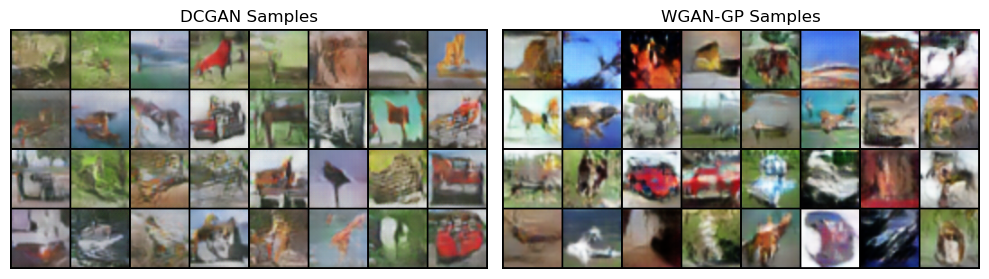

In [24]:
# Cell 4: Visual comparison – DCGAN vs WGAN-GP sample grids

import matplotlib.pyplot as plt
from torchvision import utils as vutils

num_show = 32
nrow = 8

with torch.no_grad():
    z_dcgan = torch.randn(num_show, latent_dim_dcgan, 1, 1, device=device)
    z_wgan  = torch.randn(num_show, latent_dim_wgan,  1, 1, device=device)

    samples_dcgan = G_dcgan(z_dcgan).cpu()
    samples_wgan  = G_wgan(z_wgan).cpu()

samples_dcgan_denorm = denorm(samples_dcgan).clamp(0, 1)
samples_wgan_denorm  = denorm(samples_wgan).clamp(0, 1)

grid_dcgan = vutils.make_grid(samples_dcgan_denorm, nrow=nrow)
grid_wgan  = vutils.make_grid(samples_wgan_denorm,  nrow=nrow)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("DCGAN Samples")
plt.axis("off")
plt.imshow(grid_dcgan.permute(1, 2, 0).numpy())

plt.subplot(1, 2, 2)
plt.title("WGAN-GP Samples")
plt.axis("off")
plt.imshow(grid_wgan.permute(1, 2, 0).numpy())

plt.tight_layout()
plt.show()


Batch 1: DCGAN FID = 96.86, WGAN-GP FID = 93.21
Batch 2: DCGAN FID = 92.45, WGAN-GP FID = 93.18
Batch 3: DCGAN FID = 95.08, WGAN-GP FID = 97.72
Batch 4: DCGAN FID = 84.65, WGAN-GP FID = 88.25
Batch 5: DCGAN FID = 93.16, WGAN-GP FID = 93.16


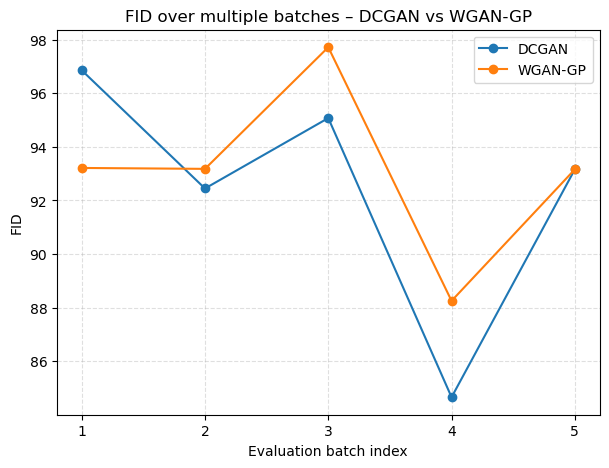

Average DCGAN FID over 5 batches: 92.44
Average WGAN-GP FID over 5 batches: 93.11


In [26]:
# Cell 6: FID over multiple batches – DCGAN vs WGAN-GP

num_eval_batches = 5   # how many different batches to evaluate on

fid_dcgan_list = []
fid_wgan_list = []

G_dcgan.eval()
G_wgan.eval()

loader_iter = iter(train_loader)

for i in range(num_eval_batches):
    try:
        real_batch, _ = next(loader_iter)
    except StopIteration:
        loader_iter = iter(train_loader)
        real_batch, _ = next(loader_iter)

    real_batch = real_batch.to(device)
    bsz = real_batch.size(0)

    with torch.no_grad():
        z_dcgan = torch.randn(bsz, latent_dim_dcgan, 1, 1, device=device)
        z_wgan  = torch.randn(bsz, latent_dim_wgan,  1, 1, device=device)

        fake_dcgan = G_dcgan(z_dcgan)
        fake_wgan  = G_wgan(z_wgan)

    real_for_fid      = denorm(real_batch).clamp(0, 1)
    fake_dcgan_fid_in = denorm(fake_dcgan).clamp(0, 1)
    fake_wgan_fid_in  = denorm(fake_wgan).clamp(0, 1)

    fid_d = calculate_fid(real_for_fid, fake_dcgan_fid_in, fid_model)
    fid_w = calculate_fid(real_for_fid, fake_wgan_fid_in,  fid_model)

    fid_dcgan_list.append(fid_d)
    fid_wgan_list.append(fid_w)

    print(f"Batch {i+1}: DCGAN FID = {fid_d:.2f}, WGAN-GP FID = {fid_w:.2f}")

# Plot
x = range(1, num_eval_batches + 1)

plt.figure(figsize=(7, 5))
plt.plot(x, fid_dcgan_list, marker="o", label="DCGAN")
plt.plot(x, fid_wgan_list, marker="o", label="WGAN-GP")
plt.xlabel("Evaluation batch index")
plt.ylabel("FID")
plt.title("FID over multiple batches – DCGAN vs WGAN-GP")
plt.xticks(x)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()

print(f"Average DCGAN FID over {num_eval_batches} batches: {np.mean(fid_dcgan_list):.2f}")
print(f"Average WGAN-GP FID over {num_eval_batches} batches: {np.mean(fid_wgan_list):.2f}")
